In [1]:
import rasterio
import numpy as np
import pandas as pd
import glob
import os

# ================================================
# Path to your directory
# ================================================
folder = r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antarctica_Vegetation_Duration\all_whole_map\Land"

# Find all tif files like Land_2002.tif ... Land_2023.tif
tif_files = sorted(glob.glob(os.path.join(folder, "Land_*.tif")))

results = []

for f in tif_files:
    year = int(os.path.basename(f).split("_")[1].split(".")[0])

    with rasterio.open(f) as src:
        arr = src.read(1).astype(float)

    # Mask invalid values (≤0)
    mask = arr > 0
    valid = arr[mask]

    if valid.size == 0:
        mean_duration = np.nan
    else:
        mean_duration = float(np.nanmean(valid))

    results.append([year, mean_duration])


# Convert to pandas DataFrame
df = pd.DataFrame(results, columns=["Year", "Mean_Duration"])
df = df.sort_values("Year")

print(df)

# Optional: save to CSV
out_csv = os.path.join(folder, "Mean_Vegetation_Duration_2002_2023.csv")
df.to_csv(out_csv, index=False)

print("\nSaved:", out_csv)

    Year  Mean_Duration
0   2000       7.205280
1   2001       7.392845
2   2002       6.731289
3   2003       7.208641
4   2004       7.632017
5   2005       7.697175
6   2006       8.501292
7   2007       8.406105
8   2008       8.294396
9   2009       8.312537
10  2010       8.683887
11  2011       8.866548
12  2012       8.721245
13  2013       8.688430
14  2014       8.721134
15  2015       9.017839
16  2016       7.397339
17  2017       8.937424
18  2018       8.817476
19  2019       9.510667
20  2020       9.664957
21  2021       8.829444
22  2022       9.549076
23  2023       9.438353

Saved: G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antarctica_Vegetation_Duration\all_whole_map\Land\Mean_Vegetation_Duration_2002_2023.csv


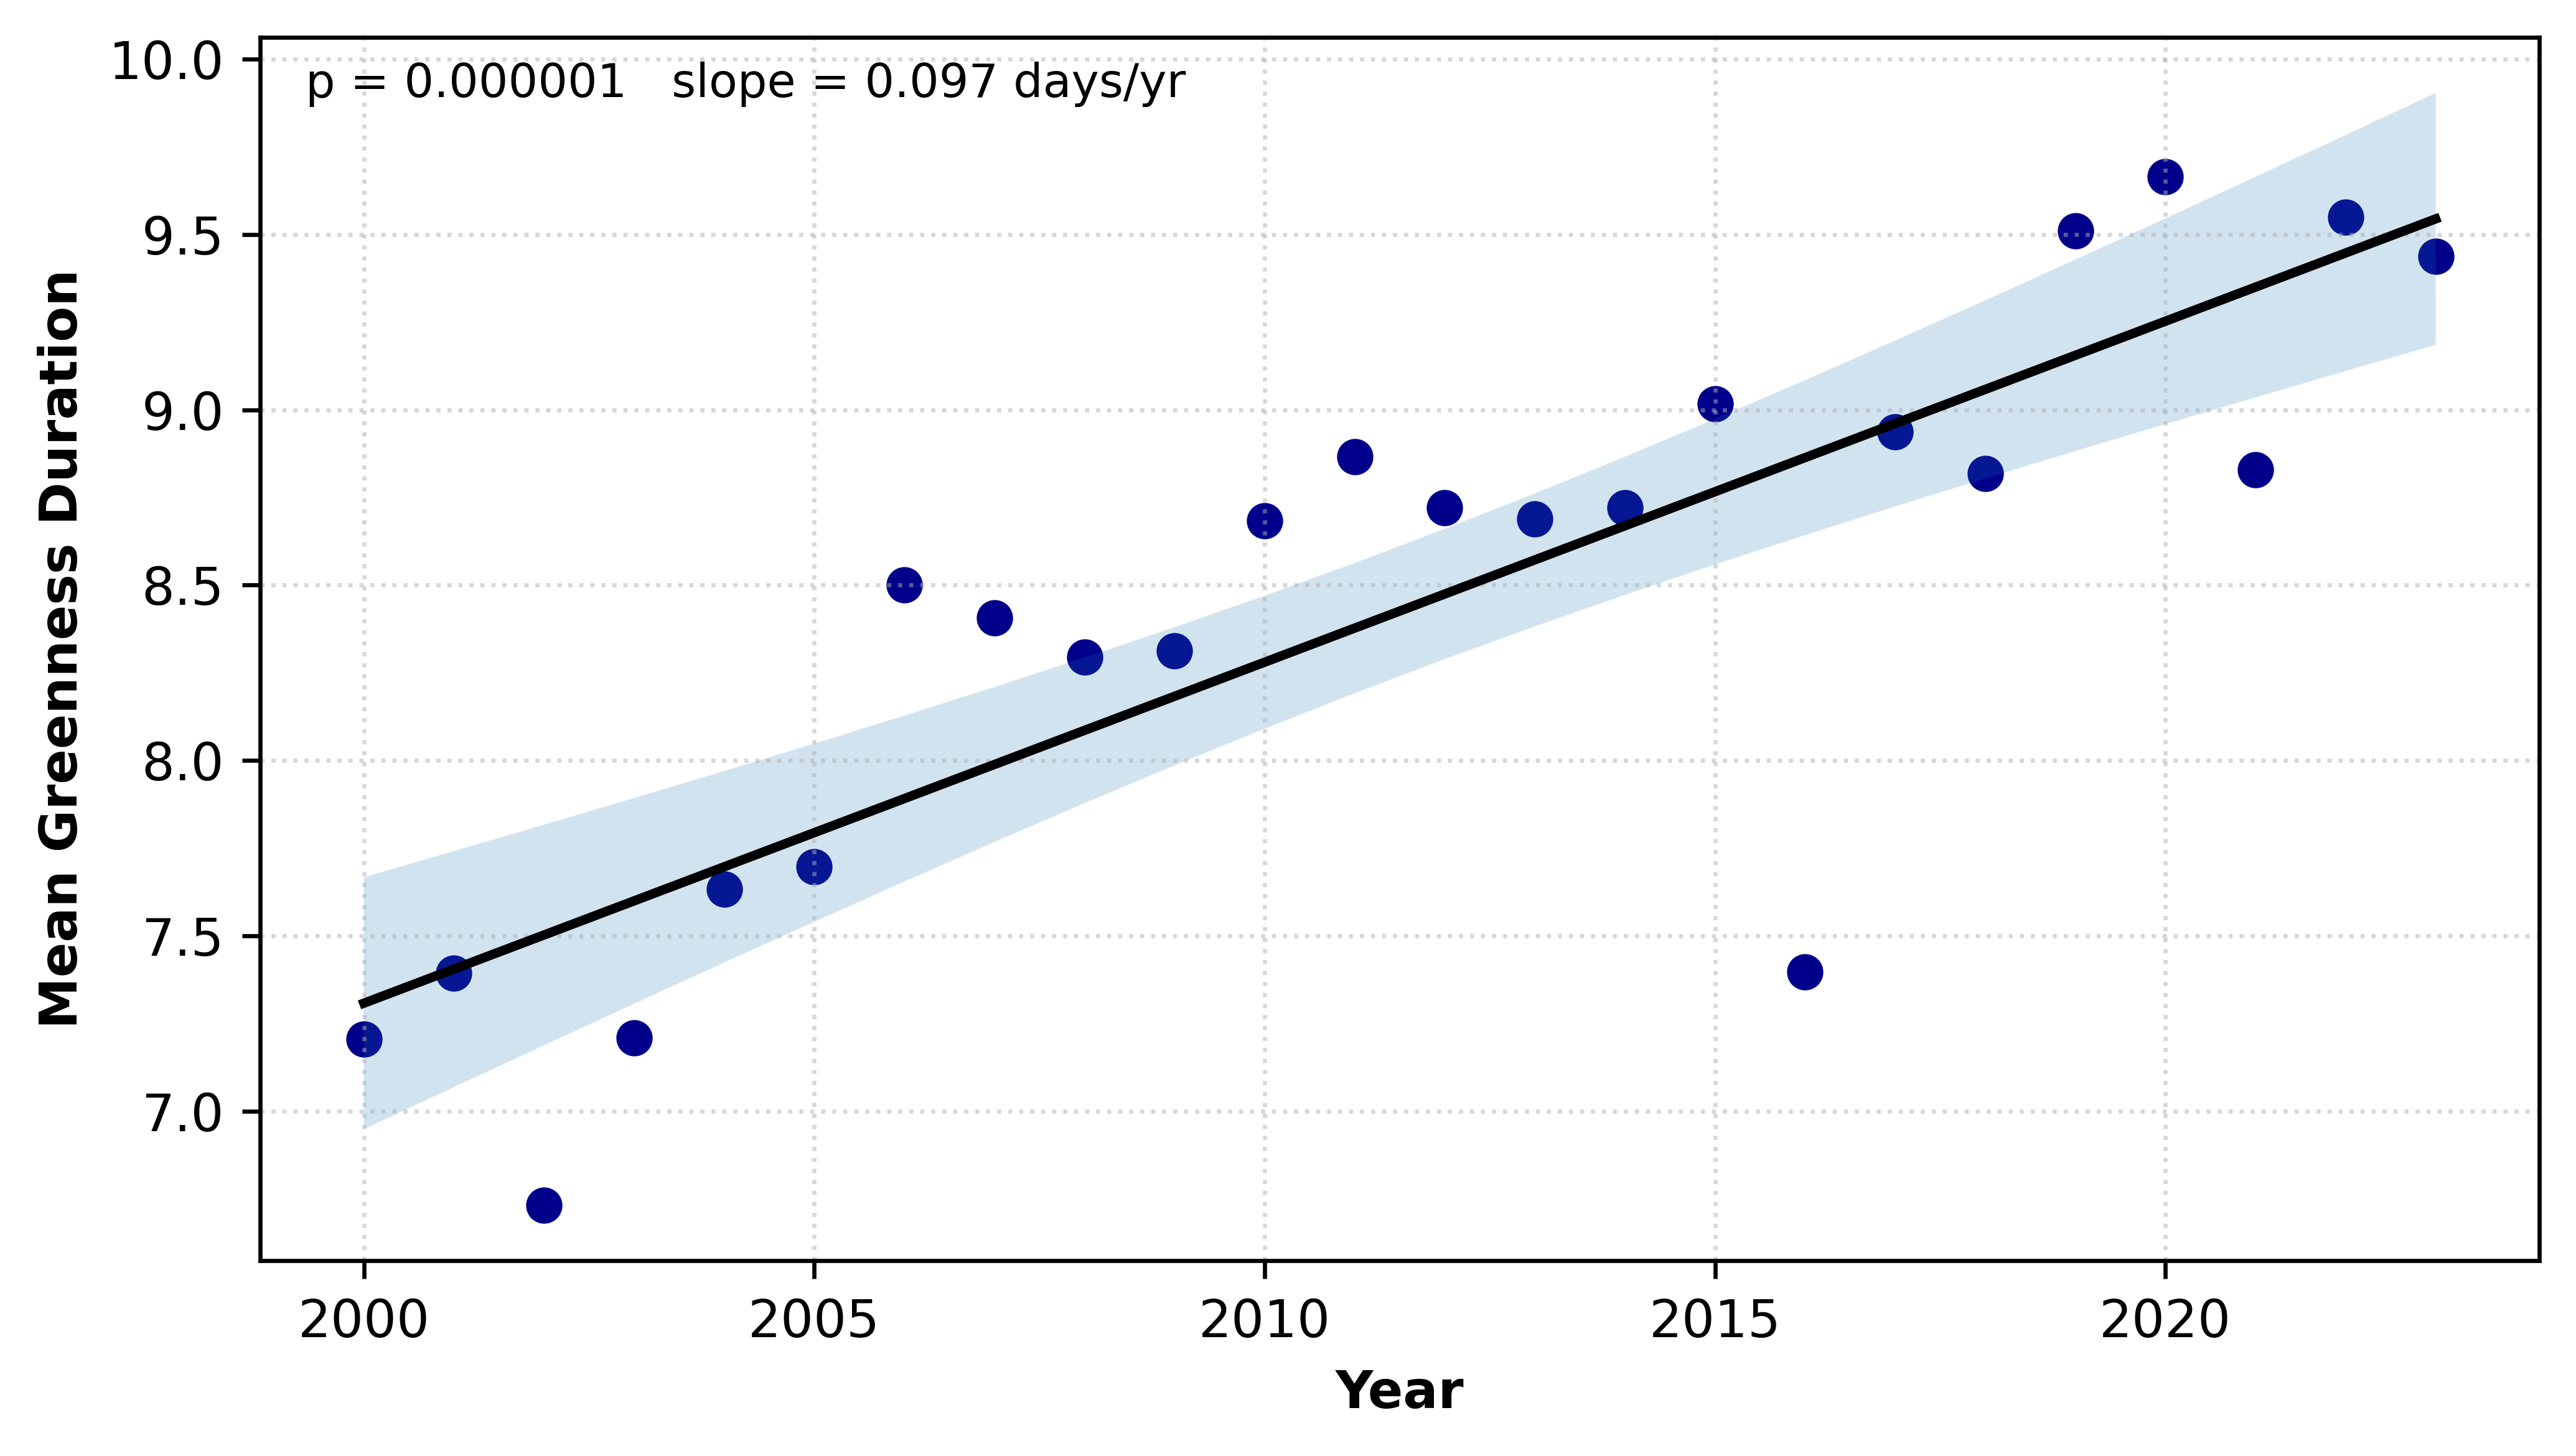

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, norm

# ======================================================
# 1. Read yearly mean duration CSV
# ======================================================
csv_path = r"G:\Hangkai\Anttarctic Vegetation Dynamic\Version_2_data\Antarctica_Vegetation_Duration\all_whole_map\Land\Mean_Vegetation_Duration_2002_2023.csv"

df = pd.read_csv(csv_path)

# Ensure the data are sorted by year
df = df.sort_values("Year")
years = df["Year"].values.astype(float)
y = df["Mean_Duration"].values.astype(float)

# Remove NaNs if any
mask = ~np.isnan(y)
years = years[mask]
y = y[mask]

# ======================================================
# 2. Mann–Kendall test + Sen's slope
# ======================================================
def mann_kendall_test(x, alpha=0.05):
    """
    Simple Mann–Kendall trend test implementation + Sen's slope.
    x: 1D array-like time series
    Returns a dict with S, Z, p, tau, trend, sen_slope, sen_intercept
    """
    x = np.asarray(x)
    n = len(x)
    
    # Compute S statistic
    S = 0
    for k in range(n - 1):
        S += np.sum(np.sign(x[k+1:] - x[k]))
    
    # Handle ties for variance of S
    unique, counts = np.unique(x, return_counts=True)
    tie_term = np.sum(counts * (counts - 1) * (2 * counts + 5))
    
    var_S = (n * (n - 1) * (2 * n + 5) - tie_term) / 18.0
    
    # Compute Z
    if S > 0:
        Z = (S - 1) / np.sqrt(var_S)
    elif S < 0:
        Z = (S + 1) / np.sqrt(var_S)
    else:
        Z = 0.0
    
    # Two-sided p-value
    p = 2 * (1 - norm.cdf(abs(Z)))
    
    # Kendall's tau
    tau = S / (0.5 * n * (n - 1))
    
    # Sen's slope
    slopes = []
    for i in range(n - 1):
        for j in range(i + 1, n):
            if (j - i) != 0:
                slopes.append((x[j] - x[i]) / (j - i))
    sen_slope = np.median(slopes)
    
    # Use median residual to get an intercept (in index space)
    idx = np.arange(n)
    sen_intercept = np.median(x - sen_slope * idx)
    
    # Trend direction
    if (p < alpha) and (Z > 0):
        trend = "increasing"
    elif (p < alpha) and (Z < 0):
        trend = "decreasing"
    else:
        trend = "no trend"
    
    return {
        "S": S,
        "Z": Z,
        "p": p,
        "tau": tau,
        "trend": trend,
        "sen_slope": sen_slope,
        "sen_intercept": sen_intercept
    }

mk_res = mann_kendall_test(y)

# ======================================================
# 3. Linear regression (LR) + 95% confidence band
# ======================================================
# Use year as the predictor
slope_lr, intercept_lr, r_value, p_value_lr, stderr = linregress(years, y)

# Fitted LR line
y_lr = intercept_lr + slope_lr * years

# Residual standard error
residuals = y - y_lr
n = len(years)
sigma = np.sqrt(np.sum(residuals**2) / (n - 2))

x_mean = np.mean(years)
Sxx = np.sum((years - x_mean)**2)

# 95% confidence interval for the regression line
t_val = 1.96  # approx for large n
se_fit = sigma * np.sqrt(1/n + (years - x_mean)**2 / Sxx)
y_lr_upper = y_lr + t_val * se_fit
y_lr_lower = y_lr - t_val * se_fit

# ======================================================
# 4. Plot: time series + LR + 95% CI + MK / Sen summary
# ======================================================
fig, ax = plt.subplots(figsize=(7, 4), dpi=600)

# Observations
ax.scatter(years, y, marker="o", color="darkblue")

# Linear regression trend line
ax.plot(years, y_lr, "-", label="Linear trend (LR)", linewidth=1.8, color = "black")

# 95% confidence envelope
ax.fill_between(years, y_lr_lower, y_lr_upper, alpha=0.2, label="95% CI (LR)")

# Axis labels and title
ax.set_xlabel("Year", fontweight="bold")
ax.set_ylabel("Mean Greenness Duration", fontweight="bold")

# Text box with MK & LR results
textstr = (
    f"p = {mk_res['p']:.6f}"
    f"   slope = {slope_lr:.3f} days/yr"
)

ax.text(
    0.02, 0.98, textstr,
    transform=ax.transAxes,
    va="top", ha="left",
    fontsize=9,
)

ax.grid(linestyle=":", alpha=0.5)

plt.tight_layout()
plt.savefig(r"C:\Users\hyou34\OneDrive - UW-Madison\manuscripts\paper\Greening Antarctica\nature_version\R1_Nature\Supplementary_Information\High_Resolution_Figures\SM_Duration_Day_Count.png",
             dpi=600, bbox_inches="tight")
plt.show()